# Student Performance Dataset - Analysis

**Task 1 - Data Science/Analysis with Python Internship (Maincrafts Technology)**

Name: Aditya

In this notebook I load the Student Performance dataset (`student-mat.csv`), clean it, answer a few analysis questions and make some basic visualizations. This is week 1 of the internship so I'm keeping things fairly simple and following the load -> clean -> analyze -> visualize -> conclude workflow given in the task doc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# just so the plots look a little nicer
sns.set_style("whitegrid")

## 1. Load Dataset

The dataset is semicolon separated (not comma separated like a normal csv), so I had to set `sep=';'` otherwise pandas reads the whole row as a single column.

In [2]:
df = pd.read_csv("student-mat.csv", sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 2. Explore & Clean Data

First checking the shape, column types and whether there are any missing values or duplicate rows.

In [3]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (395, 33)
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395

In [4]:
# check for missing values
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [5]:
# total missing values in the whole dataset
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


Good, there aren't any missing values in this dataset, so no need to fill/drop anything for that. Now checking duplicate rows.

In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

# drop duplicates anyway just in case (task asked us to)
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0
Shape after dropping duplicates: (395, 33)


Dataset was already clean (no missing values, no duplicates), so shape stays the same after this step.

## 3. Analysis Questions

### 3.1 Average final grade (G3)

In [7]:
avg_g3 = df['G3'].mean()
print("Average final grade (G3):", round(avg_g3, 2))

Average final grade (G3): 10.42


### 3.2 How many students scored above 15?

In [8]:
above_15 = df[df['G3'] > 15].shape[0]
print("Students scoring above 15 in G3:", above_15)

Students scoring above 15 in G3: 40


### 3.3 Is study time correlated with performance?

Using `.corr()` between `studytime` and `G3` to check this.

In [9]:
corr_value = df['studytime'].corr(df['G3'])
print("Correlation between studytime and G3:", round(corr_value, 3))

Correlation between studytime and G3: 0.098


A correlation of about 0.1 is very weak. So based on this dataset, study time (as reported by students) doesn't really have a strong relationship with the final grade. There's probably other factors (like past grades G1/G2, failures, etc.) that matter more.

### 3.4 Which gender performs better on average?

In [10]:
gender_avg = df.groupby('sex')['G3'].mean()
print(gender_avg)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


In this dataset, `M` = male and `F` = female. On average, male students have a slightly higher average final grade than female students, but the difference is small (less than 1 point out of 20).

## 4. Visualizations

### 4.1 Histogram of grades (G3)

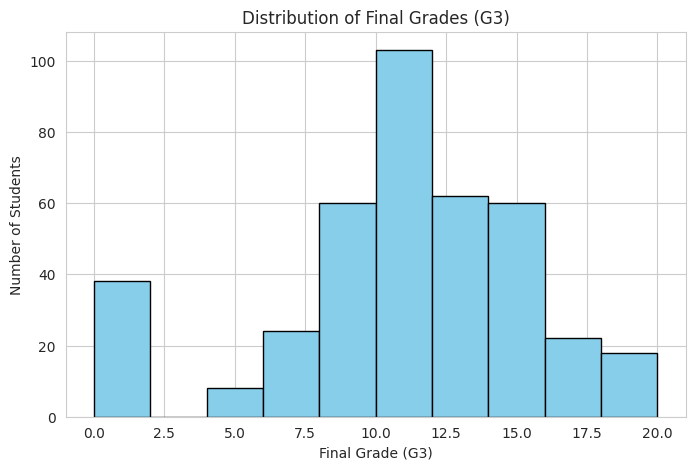

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

Most students seem to be clustered around 8-14, with a small group of students scoring 0 (probably students who dropped out or failed completely).

### 4.2 Scatterplot: study time vs grades

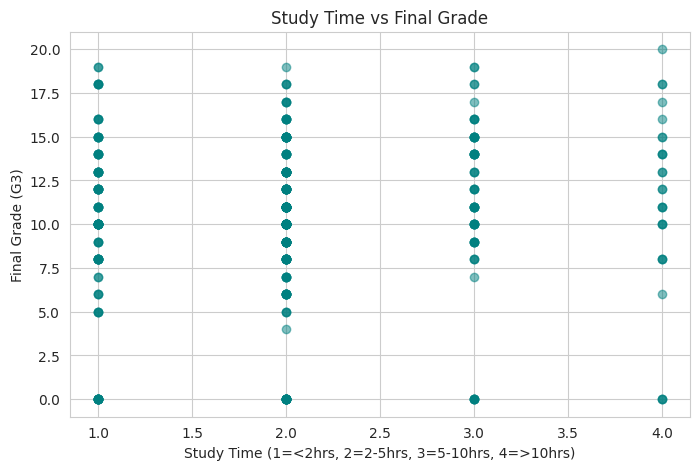

In [12]:
plt.figure(figsize=(8,5))
plt.scatter(df['studytime'], df['G3'], alpha=0.5, color='teal')
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)")
plt.ylabel("Final Grade (G3)")
plt.show()

This matches the weak correlation number from before, the points are pretty scattered across all study time levels, no obvious upward trend.

### 4.3 Bar chart: male vs female average score

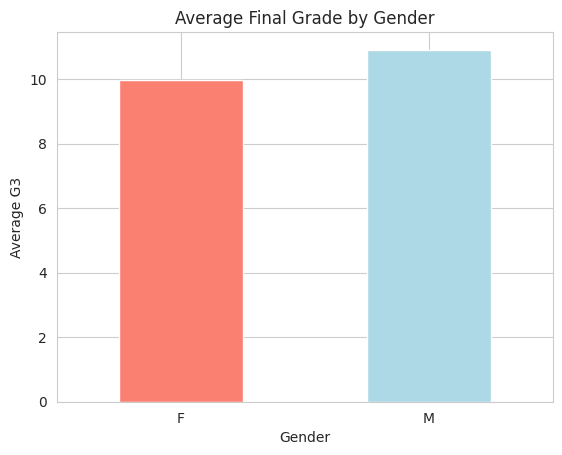

In [13]:
gender_avg.plot(kind='bar', color=['salmon', 'lightblue'])
plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average G3")
plt.xticks(rotation=0)
plt.show()

## 5. Conclusion

- The dataset had no missing values and no duplicate rows, so cleaning was minimal.
- The average final grade (G3) is around 10.4 out of 20.
- 40 students scored above 15.
- Study time and final grade have a very weak positive correlation (~0.1), so more self-reported study time doesn't strongly predict a better grade in this dataset.
- Male students scored slightly higher on average than female students, but the gap is small.

Overall this was a good first task to practice the basic pandas/matplotlib workflow - loading data, checking it's clean, answering some questions with groupby/corr, and plotting a few basic charts.